In [67]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [68]:
import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape

(5549563, 6)

In [69]:
#Subset the AnnData to only contain proximal tubules
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()]
ctrl1_A2_PT.shape #to check the dimensions of the subset matrix.
ctrl1_A2_PT.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929
...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938


In [194]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")
gdf.head()
gdf.shape

(11653, 6)

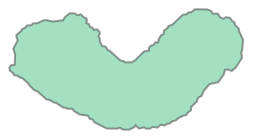

In [195]:
#Sanity Check
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

In [196]:
#Remove invlid geojsons:
gdf = gdf[gdf.geometry.notna()]
gdf = gdf[~gdf.geometry.is_empty]
gdf = gdf[gdf.is_valid]
gdf.shape

(11644, 6)

In [201]:
#Bootstrapping a few oproximal tubule instances to perform linear regression on:
import pandas as pd

PT_id=ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].unique()
PT_id_rand=pd.Series(PT_id).sample(n=5, random_state=53) #randomly select 10 proximal tubule (geojson IDs)
print(PT_id_rand.tolist())

print(len(subset))


[1924, 4644, 876, 441, 4575]
389


1924
Tubule geometry is ok
POLYGON ((9500.76 14342, 9496.42 14342.06, 9494.7 14343.07, 9493.01 14351.25, 9494.66 14355.87, 9501 14361.5, 9501.1 14365.76, 9502.8 14369.04, 9507.56 14371.97, 9517 14371.83, 9522 14373, 9524.38 14372.02, 9527.57 14375.64, 9537.76 14379, 9537 14380.85, 9537.43 14384.54, 9538.99 14385.82, 9541.76 14386, 9541.89 14386.14, 9539.99 14386.17, 9533.51 14389.33, 9532.03 14394.56, 9532 14400.76, 9530.06 14403.41, 9530 14407.76, 9529 14410, 9530 14412.24, 9530.01 14417.29, 9530.76 14419, 9530.02 14421.34, 9532 14425.71, 9532.59 14429.79, 9534.41 14430.94, 9538.29 14430.99, 9541.19 14429.05, 9542 14430.24, 9542.59 14435.79, 9544.13 14436.87, 9547 14437.24, 9547.76 14441, 9546.13 14443.13, 9546.01 14446.29, 9547.85 14448.77, 9551.41 14448.65, 9553.24 14446, 9555.53 14445.58, 9557.5 14443.33, 9563.46 14448.57, 9566.73 14448.91, 9568.57 14447.54, 9569 14445.24, 9571.67 14444.49, 9572.96 14442.47, 9574.1 14445.32, 9579 14446, 9581 14449.24, 9581 14451.76, 9580.01 14453.7

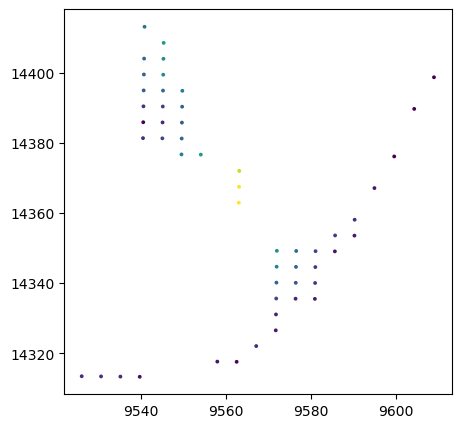

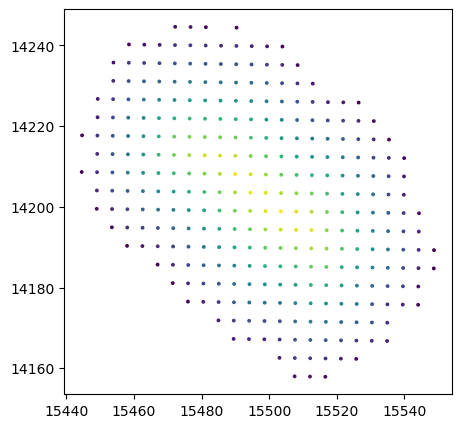

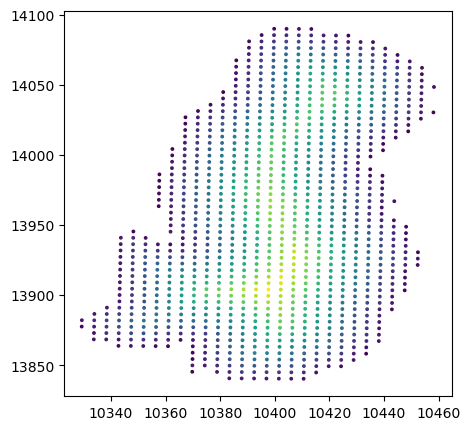

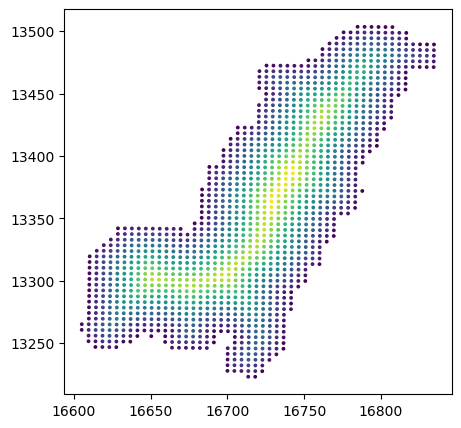

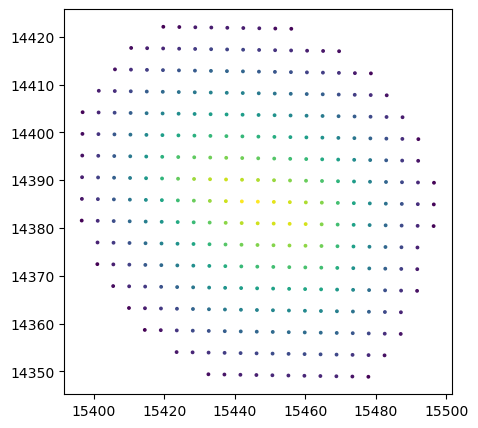

In [202]:
#for ptid in PT_id_rand.tolist():
for ptid in PT_id_rand.tolist():
  

   print(ptid) #to check what proximal tubule are we working with?

   tubule=gdf[gdf["id"]==str(ptid)]

   if tubule.empty:
    print(f"Skipping ptid={ptid} (not found in gdf)")
    continue
   else:
     print("Tubule geometry is ok")

   geom=tubule.geometry.iloc[0] 
   print(geom) #to check the associated geometry with the corresponding proximal tubule.

   subset = ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str) == str(ptid)].copy() #subset contains only 929 PT 2um bins.

   x = subset.obs["pxl_col_in_fullres"]
   y = subset.obs["pxl_row_in_fullres"]
   #print(x.head())

   #Convert bins to shapely points:
   from shapely.geometry import Point
   points = [Point(xy) for xy in zip(x, y)]

   #Extract the polygon boundary:
   boundary = geom.boundary

   #Computing distance to edge:
   distances = [p.distance(boundary) for p in points]

   #Append this new distance matrix into the subset data:
   subset.obs["dist_to_edge"] = distances

   print(subset.obs.head())
   print("SAMI")

   #Plot/Overlay
   import matplotlib.pyplot as plt
   fig, ax = plt.subplots(figsize=(5,5))
  
   # plotting the polygon (from the geojson file)
   #gdf[gdf["id"]==str(ptid)].plot(ax=ax, color="none", edgecolor="red", linewidth=2)
   #tubule.plot(ax=ax, color="none", edgecolor="red", linewidth=2)

   # plot the Visium HD bins scatter 
   sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=subset.obs["dist_to_edge"].values,
    s=3,
    cmap="viridis"
    )


   